前回用いた、Jena Climate Datasetに対して、、正則化の効果の確認を行う。
そのため、実際に用いたデータや、モデルの構成はJena_climateの時のまま使用する。
また、前処理の詳しいことに関しては、別Jena_climateのフォルダで確認してもらう。
モデルはKNNで考える。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
import math

前処理一覧

In [2]:
df=pd.read_csv("jena_climate_2009_2016.csv")
df['day']=pd.to_datetime(df['Date Time'],dayfirst=True)
df.drop("Date Time",axis=1,inplace=True)
df_day = df.resample('D', on='day').mean().reset_index()
df_nan_rows = df_day[df_day.isnull().any(axis=1)]
ideal_range = pd.date_range(start=df_day['day'].min(), end=df_day['day'].max(), freq='D')
df_indexed = df_day.set_index('day').reindex(ideal_range)
missing_dates = df_indexed[df_indexed.isnull().any(axis=1)].index
df_nonan = df_indexed.interpolate(method='linear')
df_p=df_nonan.reset_index().rename({'index':"day"},axis=1)
timestamp_s = df_p.day.map(pd.Timestamp.timestamp) 
day_seconds = 24 * 60 * 60
year_seconds = (365.2425) * day_seconds
df_p['Year_sin'] = np.sin(timestamp_s * (2 * np.pi / year_seconds))
df_p['Year_cos'] = np.cos(timestamp_s * (2 * np.pi / year_seconds))
wd_rad = df_p['wd (deg)'] * np.pi / 180
df_p['Wx'] = df_p['wv (m/s)'] * np.cos(wd_rad)
df_p['Wy'] = df_p['wv (m/s)'] * np.sin(wd_rad)
cols_to_drop = [
    'day', 
    'wv (m/s)', 'max. wv (m/s)', 'wd (deg)',
    'Tpot (K)', 'Tdew (degC)',
    'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)'
]
df_final = df_p.drop(columns=cols_to_drop)
n = len(df_final)
train_df = df_final[0:int(n*0.7)]
val_df = df_final[int(n*0.7):int(n*0.9)]
test_df = df_final[int(n*0.9):]

scaler = StandardScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

print("Trainデータの形状:", train_scaled.shape)
print("Valデータの形状:", val_scaled.shape)
print("Testデータの形状:", test_scaled.shape)
train_df = pd.DataFrame(train_scaled, columns=df_final.columns, index=train_df.index)
val_df = pd.DataFrame(val_scaled, columns=df_final.columns, index=val_df.index)
test_df = pd.DataFrame(test_scaled, columns=df_final.columns, index=test_df.index)

class data_load(Dataset):
    def __init__(self,df,input_width,label_width,shift,label_col=None):
        self.df=df
        self.input_width=input_width
        self.label_width=label_width
        self.total_window_size=input_width+shift
        self.label_columns=label_col
        if label_col is not None:
            col_ind={name:i for i,name in  enumerate(df.columns)}
            self.lab_ind=[col_ind[name] for name in self.label_columns]
        self.data = torch.tensor(df.values.astype('float32'))
    def __len__(self):
        return len(self.data)-self.total_window_size+1
    
    def __getitem__(self, i):
        window=self.data[i:i+self.total_window_size]
        inputs = window[:self.input_width, :]
        label_start = self.total_window_size - self.label_width
        labels = window[label_start:, :]
        if self.label_columns is not None:
            labels=labels[:,self.lab_ind]
        return inputs,labels

def create_dataloader(df, input_width=7, label_width=7, shift=7, batch_size=32, shuffle=False):
    dataset = data_load(
        df=df, 
        input_width=input_width, 
        label_width=label_width, 
        shift=shift, 
        label_col=label_cols  
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    return dataloader

label_cols=['T (degC)']
train_loader = create_dataloader(
    df=train_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=True
)
val_loader = create_dataloader(
    df=val_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)
test_loader = create_dataloader(
    df=test_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)


Trainデータの形状: (2046, 8)
Valデータの形状: (584, 8)
Testデータの形状: (293, 8)


CNNの設定

In [3]:
class time_ser(nn.Module):
    def __init__(self,in_cha,conv_cha):#入力が[32,14,8]
        super().__init__()
        self.conv1=nn.Conv1d(in_cha,conv_cha,kernel_size=3,padding=1,bias=True)
        self.relu1=nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(conv_cha, conv_cha, kernel_size=3, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)
        self.avgpool = nn.AvgPool1d(2, 2) #最後の次元に作用,maxもある
    
    def forward(self,input):
        block_out=self.conv1(input)
        block_out=self.relu1(block_out)
        block_out=self.conv2(block_out)
        block_out=self.relu2(block_out)
        return self.avgpool(block_out)

class time_NN(nn.Module):
      def __init__(self,in_cha,conv_cha):
          super().__init__()
          self.block1 = time_ser(in_cha, conv_cha)
          self.block2 = time_ser(conv_cha, conv_cha*2) 
          self.head_linear = nn.Linear(64*3, 14)
          self._init_weights()

      def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv1d}:
                nn.init.kaiming_normal_(
                    m.weight.data, a=0, mode='fan_out', nonlinearity='relu',
                )#平均0の正規分布からランダムに選ぶ
                if m.bias is not None:
                    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out)
                    nn.init.uniform_(m.bias, -bound, bound)
      def forward(self, input_batch):
            input_batch = input_batch.permute(0, 2, 1)#次元置き換え,特徴量が真ん中に来るように設定
            block_out = self.block1(input_batch)  # [B, 32, 7]
            block_out = self.block2(block_out)  # [B, 64, 3]
            conv_flat = block_out.view(block_out.size(0), -1) # [B, 96]
            linear_output = self.head_linear(conv_flat)      
            kekka=linear_output.unsqueeze(-1)
            return kekka
      

まずは、モデルとして、アリーストッピングなしで、指定回数(100回)計算させる。
基本的な比較としては、valデータに対して、どのくらいから精度が悪くなるのかの確認をおの

In [4]:
model= time_NN(in_cha=8, conv_cha=32).to("cuda")
loss_fn = nn.HuberLoss(delta=0.3)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epoch = 50
train_losss=[]
val_losss=[]
for i in range(epoch):
    model.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losss.append(avg_train_loss)
    model.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    val_losss.append(avg_val_loss)


どのくらい予測精度がかわるのか(overfitting)するのか確認.

結果としては、かなり早期からOverfittingを起こしていることがわかる。
そのため、いろいろな対策をとる必要がある。

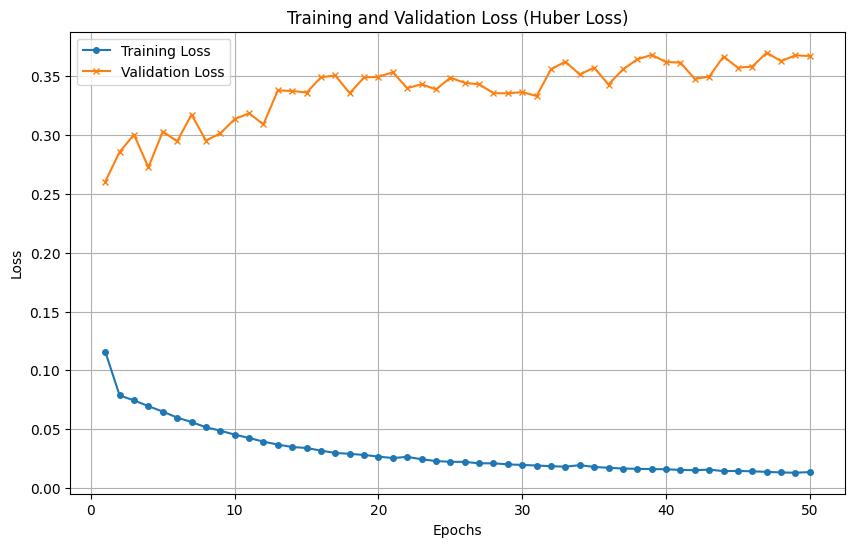

In [5]:
plt.figure(figsize=(10, 6))
epochs = range(1, epoch + 1)
plt.plot(epochs, train_losss, label='Training Loss', marker='o', markersize=4)
plt.plot(epochs, val_losss, label='Validation Loss', marker='x', markersize=4)
plt.title('Training and Validation Loss (Huber Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

対策1.L2正則化を入れてみる(Huber loss)

In [6]:
model1= time_NN(in_cha=8, conv_cha=32).to("cuda")
loss_fn = nn.HuberLoss(delta=0.3)
optimizer = optim.Adam(model1.parameters(), lr=0.001,weight_decay=1e-5)#正則化を加える

epoch = 50
train_losss1=[]
val_losss1=[]
for i in range(epoch):
    model1.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model1(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losss1.append(avg_train_loss)
    model1.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model1(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    val_losss1.append(avg_val_loss)

かなり、安定した。ただし先ほどのモデルにも該当するが、valに対して誤差が早い段階のeopchで最小に近い値を迎える。
恐らく、モデルの限界であろうが、それでも、ほかの正則化を試すことで何かいい方法がないか考える。

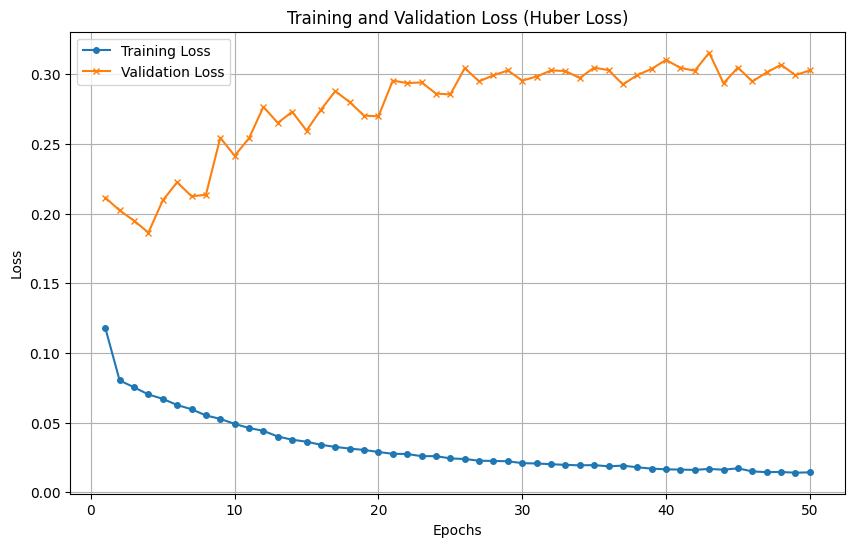

In [7]:
plt.figure(figsize=(10, 6))
epochs = range(1, epoch + 1)
plt.plot(epochs, train_losss1, label='Training Loss', marker='o', markersize=4)
plt.plot(epochs, val_losss1, label='Validation Loss', marker='x', markersize=4)
plt.title('Training and Validation Loss (Huber Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

対策2.dropoutを入れる

In [8]:
class time_ser_1(nn.Module):
    def __init__(self,in_cha,conv_cha,block_dropout_p=0.1):#入力が[32,14,8]
        super().__init__()
        self.conv1=nn.Conv1d(in_cha,conv_cha,kernel_size=3,padding=1,bias=True)
        self.relu1=nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(conv_cha, conv_cha, kernel_size=3, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)
        self.avgpool = nn.AvgPool1d(2, 2) #最後の次元に作用,maxもある
        self.dropout = nn.Dropout(p=block_dropout_p)
    def forward(self,input):
        block_out=self.conv1(input)
        block_out=self.relu1(block_out)
        block_out=self.conv2(block_out)
        block_out=self.relu2(block_out)
        block_out = self.dropout(block_out)
        return self.avgpool(block_out)

class time_NN_1(nn.Module):
      def __init__(self,in_cha,conv_cha,fc_dropout_p=0.5):
          super().__init__()
          self.block1 = time_ser_1(in_cha, conv_cha)
          self.block2 = time_ser_1(conv_cha, conv_cha*2) 
          self.fc_dropout = nn.Dropout(p=fc_dropout_p)
          self.head_linear = nn.Linear(64*3, 14)
          self._init_weights()

      def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv1d}:
                nn.init.kaiming_normal_(
                    m.weight.data, a=0, mode='fan_out', nonlinearity='relu',
                )#平均0の正規分布からランダムに選ぶ
                if m.bias is not None:
                    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out)
                    nn.init.uniform_(m.bias, -bound, bound)
      def forward(self, input_batch):
            input_batch = input_batch.permute(0, 2, 1)#次元置き換え,特徴量が真ん中に来るように設定
            block_out = self.block1(input_batch)  # [B, 32, 7]
            block_out = self.block2(block_out)  # [B, 64, 3]
            conv_flat = block_out.view(block_out.size(0), -1) # [B, 96]
            conv_flat = self.fc_dropout(conv_flat)
            linear_output = self.head_linear(conv_flat)      
            kekka=linear_output.unsqueeze(-1)
            return kekka

In [9]:
model2= time_NN_1(in_cha=8, conv_cha=32).to("cuda")
loss_fn = nn.HuberLoss(delta=0.3)
optimizer = optim.Adam(model2.parameters(), lr=0.001)

epoch = 50
train_losss2=[]
val_losss2=[]
for i in range(epoch):
    model2.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model2(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losss2.append(avg_train_loss)
    model2.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model2(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    val_losss2.append(avg_val_loss)

今までで一番よい、ただし、これもeopchが20超えるとギザギザなグラフになっている。もしかしたら、終盤になると今の学習率では大きくて、損失関数の一番底の付近で値が安定しないのかもしれない。

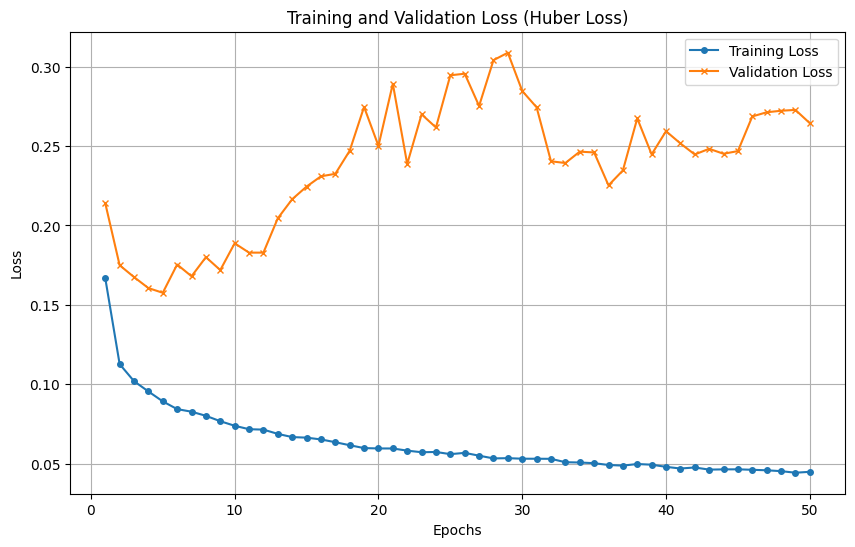

In [10]:
plt.figure(figsize=(10, 6))
epochs = range(1, epoch + 1)
plt.plot(epochs, train_losss2, label='Training Loss', marker='o', markersize=4)
plt.plot(epochs, val_losss2, label='Validation Loss', marker='x', markersize=4)
plt.title('Training and Validation Loss (Huber Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

ここで、モデル3として、新たに学習率を途中で変えるというモデルを作る。
#ReduceLROnPlateauという手法もあるが今回はしない

In [13]:
model3= time_NN_1(in_cha=8, conv_cha=32).to("cuda")
loss_fn = nn.HuberLoss(delta=0.3)
optimizer = optim.Adam(model3.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)#StepLRの定義:step_size=10(10エポックごとに),gamma=0.5(学習率を半分（0.5倍))

epoch = 50
train_losss3=[]
val_losss3=[]
for i in range(epoch):
    model3.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model3(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losss3.append(avg_train_loss)
    model3.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model3(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    scheduler.step()
    val_losss3.append(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {i+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

Epoch  1 | Train Loss: 0.1796 | Val Loss: 0.1732 | LR: 0.001000
Epoch  2 | Train Loss: 0.1163 | Val Loss: 0.1908 | LR: 0.001000
Epoch  3 | Train Loss: 0.1040 | Val Loss: 0.1830 | LR: 0.001000
Epoch  4 | Train Loss: 0.0992 | Val Loss: 0.1880 | LR: 0.001000
Epoch  5 | Train Loss: 0.0944 | Val Loss: 0.1460 | LR: 0.001000
Epoch  6 | Train Loss: 0.0899 | Val Loss: 0.1516 | LR: 0.001000
Epoch  7 | Train Loss: 0.0848 | Val Loss: 0.1625 | LR: 0.001000
Epoch  8 | Train Loss: 0.0839 | Val Loss: 0.1303 | LR: 0.001000
Epoch  9 | Train Loss: 0.0798 | Val Loss: 0.1410 | LR: 0.001000
Epoch 10 | Train Loss: 0.0768 | Val Loss: 0.1559 | LR: 0.000500
Epoch 11 | Train Loss: 0.0734 | Val Loss: 0.1457 | LR: 0.000500
Epoch 12 | Train Loss: 0.0726 | Val Loss: 0.1577 | LR: 0.000500
Epoch 13 | Train Loss: 0.0714 | Val Loss: 0.1686 | LR: 0.000500
Epoch 14 | Train Loss: 0.0710 | Val Loss: 0.1589 | LR: 0.000500
Epoch 15 | Train Loss: 0.0701 | Val Loss: 0.1512 | LR: 0.000500
Epoch 16 | Train Loss: 0.0695 | Val Loss

設定したStepLRによって学習率が段階的に下がり前のように大きくギザギザになることが格段に減った。
本来この場合、アーリーストッピングで、epoch=6~17くらいのところのモデルを採用すればいい。
ただ、今回は、あくまで正則化によるモデル精度の向上確認をしたいので、ほかの方法がないか確認する。
案としては、これに少しだけ正則化を加えるというものもあるが、もう一つの正則化の技術、バッチ正規化を試してみる。

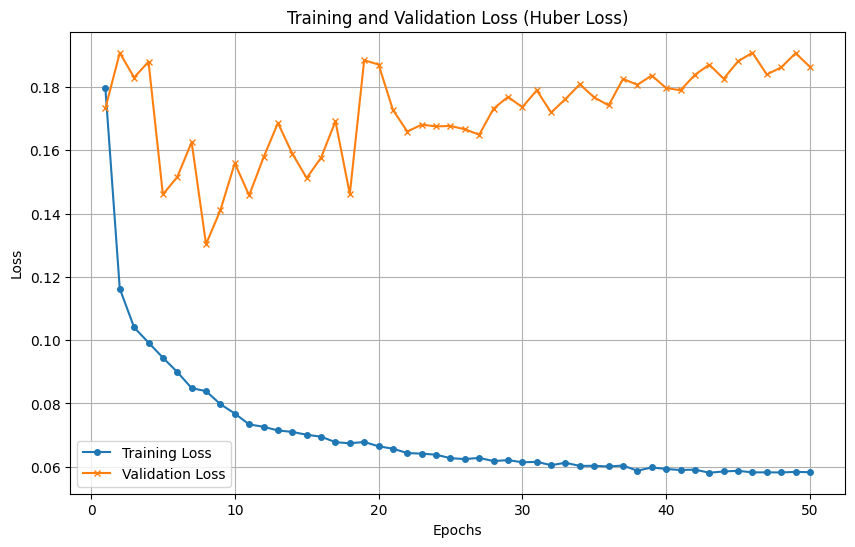

In [14]:
plt.figure(figsize=(10, 6))
epochs = range(1, epoch + 1)
plt.plot(epochs, train_losss3, label='Training Loss', marker='o', markersize=4)
plt.plot(epochs, val_losss3, label='Validation Loss', marker='x', markersize=4)
plt.title('Training and Validation Loss (Huber Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

バッチ正規化やレイヤー正規化などがあるが、今回はCNNなのでバッチ正規化を用いる。
dropoutに関しては、最後の層だけ残す(なかったら極端に精度が悪かったため)


In [34]:
class time_ser_2(nn.Module):
    def __init__(self, in_cha, conv_cha):
        super().__init__()
        self.conv1 = nn.Conv1d(in_cha, conv_cha, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(conv_cha)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(conv_cha, conv_cha, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(conv_cha)
        self.relu2 = nn.ReLU(inplace=True)
        
        self.avgpool = nn.AvgPool1d(2, 2) 

    def forward(self, input):
        block_out = self.conv1(input)
        block_out = self.bn1(block_out)
        block_out = self.relu1(block_out)
        
        block_out = self.conv2(block_out)
        block_out = self.bn2(block_out)
        block_out = self.relu2(block_out)
        
        return self.avgpool(block_out)

class time_NN_2(nn.Module):
      def __init__(self, in_cha, conv_cha, fc_dropout_p=0.5):
          super().__init__()
          self.block1 = time_ser_2(in_cha, conv_cha)
          self.block2 = time_ser_2(conv_cha, conv_cha*2) 
          
          # 🌟 ここ（最終防衛ライン）のDropoutは残す！
          self.fc_dropout = nn.Dropout(p=fc_dropout_p)
          self.head_linear = nn.Linear(64*3, 14)
          self._init_weights()

      def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv1d}:
                nn.init.kaiming_normal_(
                    m.weight.data, a=0, mode='fan_out', nonlinearity='relu',
                )
                if m.bias is not None:
                    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out)
                    nn.init.uniform_(m.bias, -bound, bound)
            elif type(m) == nn.BatchNorm1d:
                nn.init.constant_(m.weight, 1) 
                nn.init.constant_(m.bias, 0)   

      def forward(self, input_batch):
            input_batch = input_batch.permute(0, 2, 1)
            block_out = self.block1(input_batch)  
            block_out = self.block2(block_out)  
            
            conv_flat = block_out.view(block_out.size(0), -1) 
            conv_flat = self.fc_dropout(conv_flat)
            linear_output = self.head_linear(conv_flat)      
            
            kekka = linear_output.unsqueeze(-1)
            return kekka

In [37]:
model4= time_NN_2(in_cha=8, conv_cha=32).to("cuda")
loss_fn = nn.HuberLoss(delta=0.3)
optimizer = optim.Adam(model4.parameters(), lr=0.001)

epoch = 50
train_losss4=[]
val_losss4=[]
for i in range(epoch):
    model4.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model4(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losss4.append(avg_train_loss)
    model4.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model4(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    val_losss4.append(avg_val_loss)

精度はかなり悪い模様。
そもそも時系列データに対するアプローチとして、不適であるみたいな論文を見たこともあるので...
でも、ビックデータかつ複雑なモデルなら、学習速度の観点から良いらしいので、技術の一つとして押さえておく。

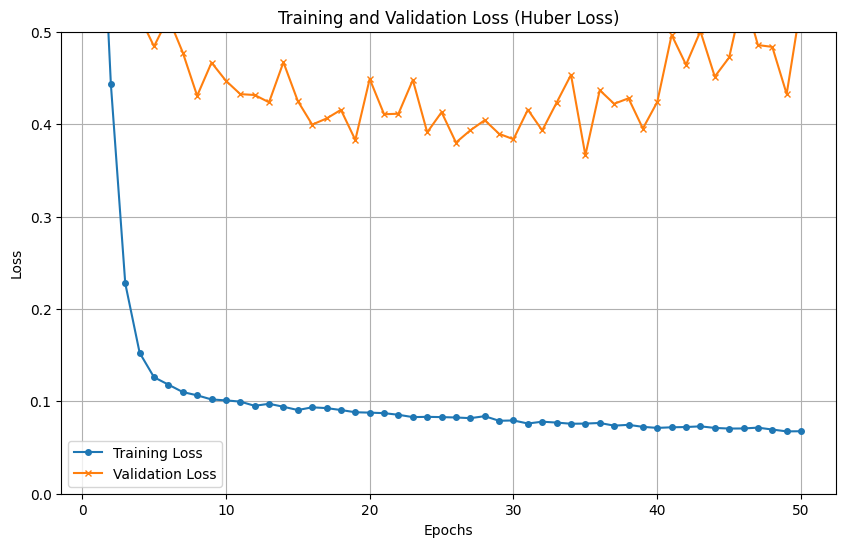

In [38]:
plt.figure(figsize=(10, 6))
epochs = range(1, epoch + 1)
plt.plot(epochs, train_losss4, label='Training Loss', marker='o', markersize=4)
plt.plot(epochs, val_losss4, label='Validation Loss', marker='x', markersize=4)
plt.ylim(0,0.5)
plt.title('Training and Validation Loss (Huber Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

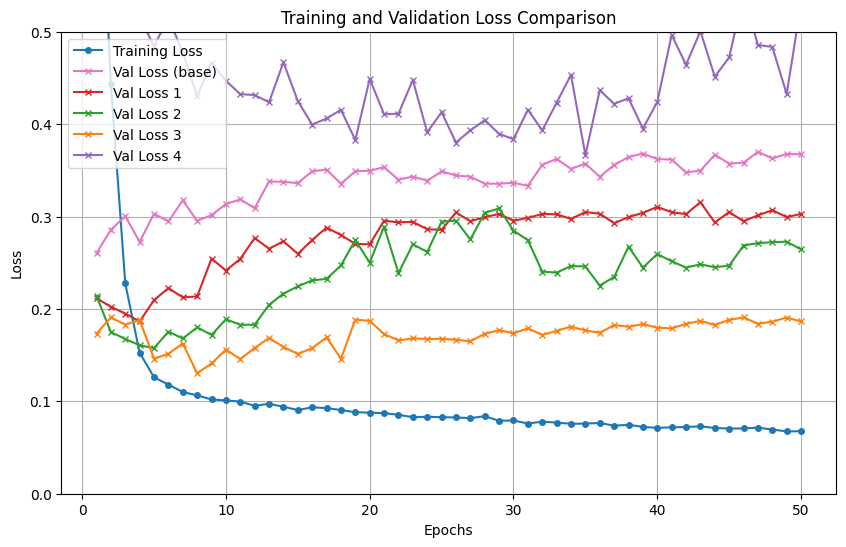

In [43]:
plt.figure(figsize=(10, 6))
epochs = range(1, epoch + 1)
plt.plot(epochs, train_losss4, label='Training Loss', marker='o', markersize=4, color='tab:blue')
plt.plot(epochs, val_losss, label='Val Loss (base) ', marker='x', markersize=4, color='tab:pink')
plt.plot(epochs, val_losss1, label='Val Loss 1 ', marker='x', markersize=4, color='tab:red')
plt.plot(epochs, val_losss2, label='Val Loss 2', marker='x', markersize=4, color='tab:green')
plt.plot(epochs, val_losss3, label='Val Loss 3', marker='x', markersize=4, color='tab:orange')
plt.plot(epochs, val_losss4, label='Val Loss 4 ', marker='x', markersize=4, color='tab:purple')

plt.ylim(0, 0.5)
plt.title('Training and Validation Loss Comparison')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)